In [1]:
import numpy as np
import pandas as pd

In [2]:
data=pd.read_csv("data.csv")

In [3]:
data.head()

,longitude,latitude,housing_median_age,total_rooms,total_bedrooms,population,households,median_income,median_house_value,ocean_proximity
0,-122.23,37.88,41.0,880.0,129.0,322.0,126.0,8.3252,452600.0,NEAR BAY
1,-122.22,37.86,21.0,7099.0,1106.0,2401.0,1138.0,8.3014,358500.0,NEAR BAY
2,-122.24,37.85,52.0,1467.0,190.0,496.0,177.0,7.2574,352100.0,NEAR BAY
3,-122.25,37.85,52.0,1274.0,235.0,558.0,219.0,5.6431,341300.0,NEAR BAY
4,-122.25,37.85,52.0,1627.0,280.0,565.0,259.0,3.8462,342200.0,NEAR BAY


In [4]:
data["ocean_proximity"].value_counts()

ocean_proximity
<1H OCEAN     9136
INLAND        6551
NEAR OCEAN    2658
NEAR BAY      2290
ISLAND           5
Name: count, dtype: int64

In [5]:
from sklearn.preprocessing import LabelEncoder
data.ocean_proximity=LabelEncoder().fit_transform(data.ocean_proximity)

In [6]:
data["ocean_proximity"].value_counts()

ocean_proximity
0    9136
1    6551
4    2658
3    2290
2       5
Name: count, dtype: int64

In [7]:
import matplotlib.pyplot as plt
x=data["longitude"]
y=data["median_house_value"]

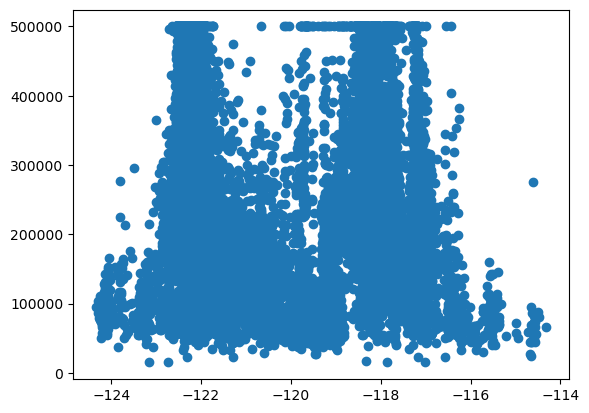

In [8]:
plt.scatter(x,y)

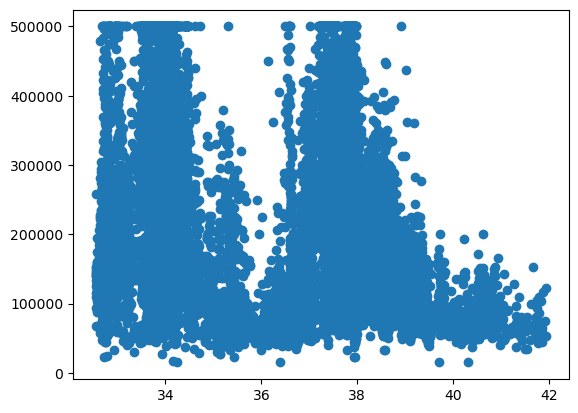

In [9]:
x=data["latitude"]
y=data["median_house_value"]
plt.scatter(x,y)

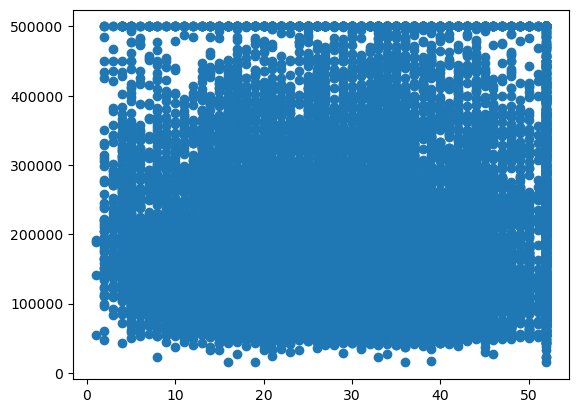

In [10]:
x=data["housing_median_age"]
y=data["median_house_value"]
plt.scatter(x,y)

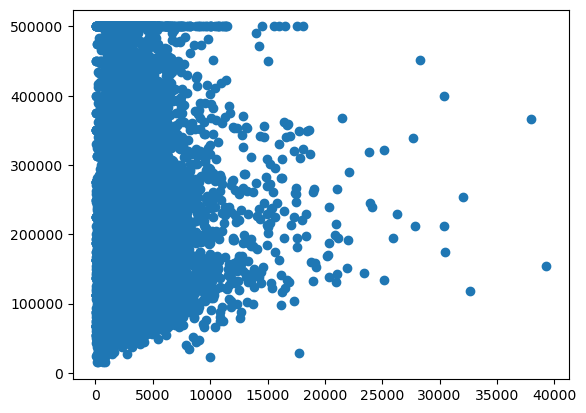

In [11]:
x=data["total_rooms"]
y=data["median_house_value"]
plt.scatter(x,y)

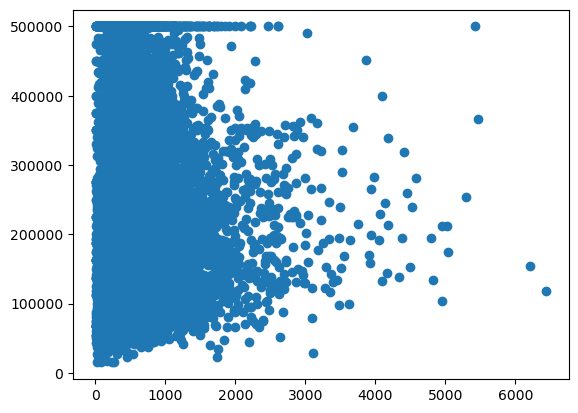

In [12]:
x=data["total_bedrooms"]
y=data["median_house_value"]
plt.scatter(x,y)

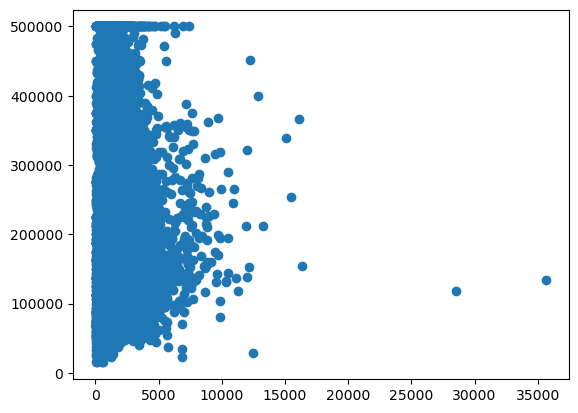

In [13]:
x=data["population"]
y=data["median_house_value"]
plt.scatter(x,y)

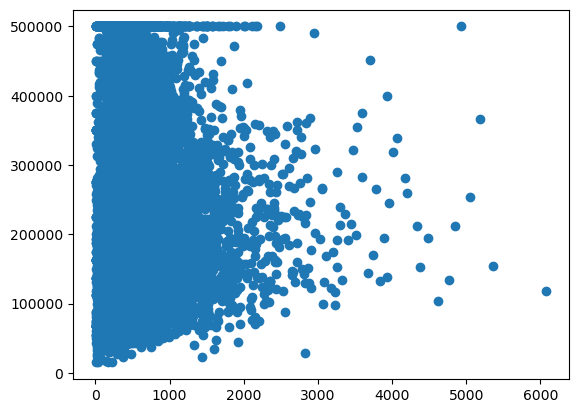

In [14]:
x=data["households"]
y=data["median_house_value"]
plt.scatter(x,y)

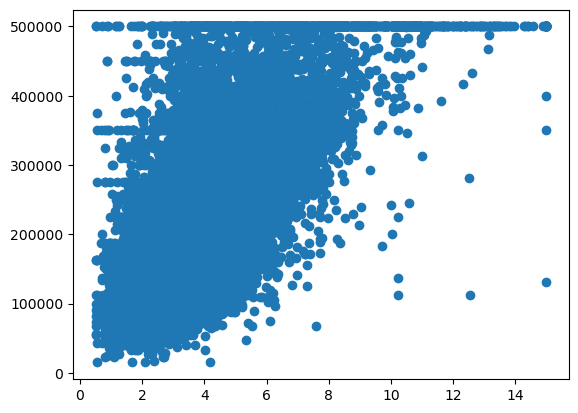

In [15]:
x=data["median_income"]
y=data["median_house_value"]
plt.scatter(x,y)

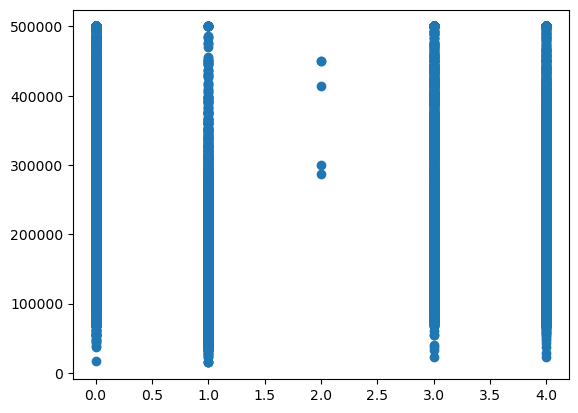

In [16]:
x=data["ocean_proximity"]
y=data["median_house_value"]
plt.scatter(x,y)

In [17]:
data=data.drop(["longitude","latitude"],axis=1)

In [18]:
data.head()

,housing_median_age,total_rooms,total_bedrooms,population,households,median_income,median_house_value,ocean_proximity
0,41.0,880.0,129.0,322.0,126.0,8.3252,452600.0,3
1,21.0,7099.0,1106.0,2401.0,1138.0,8.3014,358500.0,3
2,52.0,1467.0,190.0,496.0,177.0,7.2574,352100.0,3
3,52.0,1274.0,235.0,558.0,219.0,5.6431,341300.0,3
4,52.0,1627.0,280.0,565.0,259.0,3.8462,342200.0,3


In [19]:
data["constant"]=pd.DataFrame(np.ones(len(data)))

In [20]:
data.head()

,housing_median_age,total_rooms,total_bedrooms,population,households,median_income,median_house_value,ocean_proximity,constant
0,41.0,880.0,129.0,322.0,126.0,8.3252,452600.0,3,1.0
1,21.0,7099.0,1106.0,2401.0,1138.0,8.3014,358500.0,3,1.0
2,52.0,1467.0,190.0,496.0,177.0,7.2574,352100.0,3,1.0
3,52.0,1274.0,235.0,558.0,219.0,5.6431,341300.0,3,1.0
4,52.0,1627.0,280.0,565.0,259.0,3.8462,342200.0,3,1.0


In [21]:
train=data[:int(0.7*len(data))]
test=data[int(0.7*len(data)):]

In [22]:
trainy=train["median_house_value"]
testy=test["median_house_value"]

In [23]:
trainx=train.drop(["median_house_value"],axis=1)
testx=test.drop(["median_house_value"],axis=1)

In [24]:
theta=np.ones(8)

In [25]:
theta=pd.DataFrame(theta)

theta.head()

,0
0,1.0
1,1.0
2,1.0
3,1.0
4,1.0


In [26]:
trainx.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 14447 entries, 0 to 14446
Data columns (total 8 columns):
 #   Column              Non-Null Count  Dtype  
---  ------              --------------  -----  
 0   housing_median_age  14447 non-null  float64
 1   total_rooms         14447 non-null  float64
 2   total_bedrooms      14309 non-null  float64
 3   population          14447 non-null  float64
 4   households          14447 non-null  float64
 5   median_income       14447 non-null  float64
 6   ocean_proximity     14447 non-null  int64  
 7   constant            14447 non-null  float64
dtypes: float64(7), int64(1)
memory usage: 903.1 KB


In [27]:
testx.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 6193 entries, 14447 to 20639
Data columns (total 8 columns):
 #   Column              Non-Null Count  Dtype  
---  ------              --------------  -----  
 0   housing_median_age  6193 non-null   float64
 1   total_rooms         6193 non-null   float64
 2   total_bedrooms      6124 non-null   float64
 3   population          6193 non-null   float64
 4   households          6193 non-null   float64
 5   median_income       6193 non-null   float64
 6   ocean_proximity     6193 non-null   int64  
 7   constant            6193 non-null   float64
dtypes: float64(7), int64(1)
memory usage: 387.2 KB


In [28]:
trainx["total_bedrooms"]=trainx["total_bedrooms"].fillna(trainx["total_bedrooms"].median())
testx["total_bedrooms"]=testx["total_bedrooms"].fillna(trainx["total_bedrooms"].median())

In [29]:
trainx.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 14447 entries, 0 to 14446
Data columns (total 8 columns):
 #   Column              Non-Null Count  Dtype  
---  ------              --------------  -----  
 0   housing_median_age  14447 non-null  float64
 1   total_rooms         14447 non-null  float64
 2   total_bedrooms      14447 non-null  float64
 3   population          14447 non-null  float64
 4   households          14447 non-null  float64
 5   median_income       14447 non-null  float64
 6   ocean_proximity     14447 non-null  int64  
 7   constant            14447 non-null  float64
dtypes: float64(7), int64(1)
memory usage: 903.1 KB


In [30]:
testx.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 6193 entries, 14447 to 20639
Data columns (total 8 columns):
 #   Column              Non-Null Count  Dtype  
---  ------              --------------  -----  
 0   housing_median_age  6193 non-null   float64
 1   total_rooms         6193 non-null   float64
 2   total_bedrooms      6193 non-null   float64
 3   population          6193 non-null   float64
 4   households          6193 non-null   float64
 5   median_income       6193 non-null   float64
 6   ocean_proximity     6193 non-null   int64  
 7   constant            6193 non-null   float64
dtypes: float64(7), int64(1)
memory usage: 387.2 KB


In [31]:
trainy.head()

0    452600.0
1    358500.0
2    352100.0
3    341300.0
4    342200.0
Name: median_house_value, dtype: float64

In [32]:
testy.head()

14447    500001.0
14448    450000.0
14449    332400.0
14450    394400.0
14451    311900.0
Name: median_house_value, dtype: float64

In [33]:
trainx.head()

,housing_median_age,total_rooms,total_bedrooms,population,households,median_income,ocean_proximity,constant
0,41.0,880.0,129.0,322.0,126.0,8.3252,3,1.0
1,21.0,7099.0,1106.0,2401.0,1138.0,8.3014,3,1.0
2,52.0,1467.0,190.0,496.0,177.0,7.2574,3,1.0
3,52.0,1274.0,235.0,558.0,219.0,5.6431,3,1.0
4,52.0,1627.0,280.0,565.0,259.0,3.8462,3,1.0


In [34]:
theta.head()

,0
0,1.0
1,1.0
2,1.0
3,1.0
4,1.0


In [35]:
trainx.columns=[0,1,2,3,4,5,6,7]

In [36]:
trainy.head()

0    452600.0
1    358500.0
2    352100.0
3    341300.0
4    342200.0
Name: median_house_value, dtype: float64

In [37]:
testx.columns=[0,1,2,3,4,5,6,7]

In [38]:
testx.head()

,0,1,2,3,4,5,6,7
14447,35.0,1878.0,308.0,598.0,257.0,6.9553,4,1.0
14448,30.0,1446.0,385.0,650.0,344.0,3.7440,4,1.0
14449,33.0,1588.0,289.0,683.0,301.0,5.4103,4,1.0
14450,34.0,2420.0,391.0,917.0,392.0,6.5881,4,1.0
14451,39.0,1846.0,350.0,765.0,329.0,3.9187,4,1.0


In [39]:
trainx.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 14447 entries, 0 to 14446
Data columns (total 8 columns):
 #   Column  Non-Null Count  Dtype  
---  ------  --------------  -----  
 0   0       14447 non-null  float64
 1   1       14447 non-null  float64
 2   2       14447 non-null  float64
 3   3       14447 non-null  float64
 4   4       14447 non-null  float64
 5   5       14447 non-null  float64
 6   6       14447 non-null  int64  
 7   7       14447 non-null  float64
dtypes: float64(7), int64(1)
memory usage: 903.1 KB


In [40]:
for j in range(8):
    for i in range(10):
        hx=0
        for k in range(8):
            hx=hx+(trainx[k][i]*theta[0][k])
        p=(0.25*(hx-trainy[i])*trainx[j][i])
        theta[0][j]=theta[0][j]-p
        print(str(j)+" "+str(theta[0][j]))

0 4623670.1667
0 -503315561.294325
0 339742550737.3232
0 -229326217340636.53
0 1.5479519670934262e+17
0 -1.0448675777880279e+20
0 7.052856150069188e+22
0 -4.760677901296702e+25
0 2.094698276570549e+28
0 -1.4139213366851207e+31
1 1.2753570456899788e+35
1 -1.60681534246285e+42
1 8.645007990713103e+47
1 -3.5078676023756744e+53
1 2.3214410067346764e+59
1 -4.9014731308120457e+64
1 7.874487391040029e+70
1 -1.896730140226029e+77
1 3.095473546682116e+83
1 -9.747179555864822e+89
2 2.7662495579544362e+94
2 -8.457499200144308e+99
2 7.632047285002302e+103
2 -1.0536232078127073e+108
2 2.064996124992125e+112
2 -2.3419637302566935e+116
2 1.4000083532194744e+121
2 -1.651887356068073e+126
2 1.8262481962194483e+131
2 -2.2821025740982755e+136
3 2.3698494180723542e+140
3 -3.41527370051186e+146
3 2.1004957840795757e+151
3 -1.635025918327541e+156
3 1.30483652168609e+161
3 -5.563986033034698e+165
3 1.6647891329722462e+171
3 -5.571404122269082e+176
3 2.0258071100900163e+182
3 -1.2183188766528033e+188
4 1.2357

In [41]:
print(theta)

               0
0  -1.413921e+31
1  -9.747180e+89
2 -2.282103e+136
3 -1.218319e+188
4 -4.572052e+233
5 -4.090884e+239
6 -8.800619e+240
7  2.636445e+241


In [56]:
r=5
for k in range(8):
    r=r+(trainx[k][0]*theta[0][k])
print(r)

1.5103252e+46
